### **Introduction**
This data analysis utilizes a dataset containing life expectancy and GDP data for five countries over multiple years. By examining both temporal and cross-country variations, the study seeks to uncover patterns that illustrate how improvements in economic growth may correspond to changes in population health outcomes.

#### **Project Scope**

- Investigates the relationship between life expectancy and economic performance (GDP) across five countries over multiple years.  
- Analyzes data patterns to understand how economic growth influences population health outcomes.  
- Summarizes and visualizes key statistics using tables**, line plots, bar charts, and box plots to highlight variations and trends across time and countries.  
- Explores relationships between GDP and life expectancy through scatter plots, trend analysis, and correlation measures.  
- Applies statistical methods to evaluate the significance and strength of observed relationships between economic and health indicators.  
- Builds predictive models (e.g., regression) to estimate life expectancy based on GDP and time, assessing accuracy and reliability.  
- Combines data visualization, statistical analysis, and predictive modeling to deliver insights on the socioeconomic factors shaping global health and longevity.  


#### Data Overview
The dataset consists of 96 observations and four key attributes representing annual life expectancy and GDP data for five countries. It combines both cross-sectional and time-series characteristics, enabling comparative and trend-based analyses. The dataset comprises one categorical variable and three numeric variables:
- Categorical variable: Country
- Numeric variable: Year, Life expectancy at birth (years), GDP

This section presents the process of loading the CSV dataset and checking the data types containing life expectancy, years and GDP data for five selected countries, namely:

1. Chile
2. China
3. Germany
4. Mexico
5. United States of America
6. Zimbabwe

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import plotly.express as px
from pathlib import Path
import seaborn as sns

life_data = pd.read_csv('all_data.csv')
life_data.info()
life_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


A few data cleaning steps were performed to:
- Rename 'Life expectancy at birth (years)' to 'Life_expectancy_years'
- Update the country name from 'United States of America' to 'USA'.
- Convert GDP to billion by dividing the column value by 1e9
- Create GDP_in_billion and drop GDP

In [12]:
life_data.rename(columns={'Life expectancy at birth (years)': 'Life_expectancy_years'}, inplace=True)
life_data['Country'].replace({'United States of America': 'USA'}, inplace=True)
life_data['GDP_in_trillion'] = life_data['GDP'] / 1e12
life_data.drop(columns=['GDP'], inplace=True)

/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_25508/3551497587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  life_data['Country'].replace({'United States of America': 'USA'}, inplace=True)


#### Summary statistics
This stage focuses on identifying central tendencies, dispersion, and overall trends to build an initial understanding of the data before deeper exploration and modeling.
These statistics provide insight into the range and variability of life expectancy and GDP across all observations. 
- The mean and standard deviation help establish the central tendency and spread of each variable, 
- Minimum and Maximum values indicate the observed extremes across the dataset.
- Average of Life expectancy and GDP across the five selected countries


Describe function is used to get a summary of the numeric variables GDP and Life expectancy at birth (years).

In [13]:
life_data.describe()[['Life_expectancy_years', 'GDP_in_trillion']]

,Life_expectancy_years,GDP_in_trillion
count,96.000000,96.000000
mean,72.789583,3.880499
std,10.672882,5.197561
min,44.300000,0.004416
25%,74.475000,0.173302
50%,76.750000,1.280220
75%,78.900000,4.067510
max,81.000000,18.100000


This table highlights the average life expectancy and GDP for each country, offering a quick comparison of relative economic performance and health outcomes.

In [14]:
life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].mean().round(2)

,Life_expectancy_years,GDP_in_trillion
Country,,
Chile,78.94,0.17
China,74.26,4.96
Germany,79.66,3.09
Mexico,75.72,0.98
USA,78.06,14.08
Zimbabwe,50.09,0.01


The box plot illustrates the distribution of life expectancy across countries, showing both the median and variability. A narrow box indicates low variation over time, while a wider box suggests more fluctuation.

/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_25508/1409653414.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2')


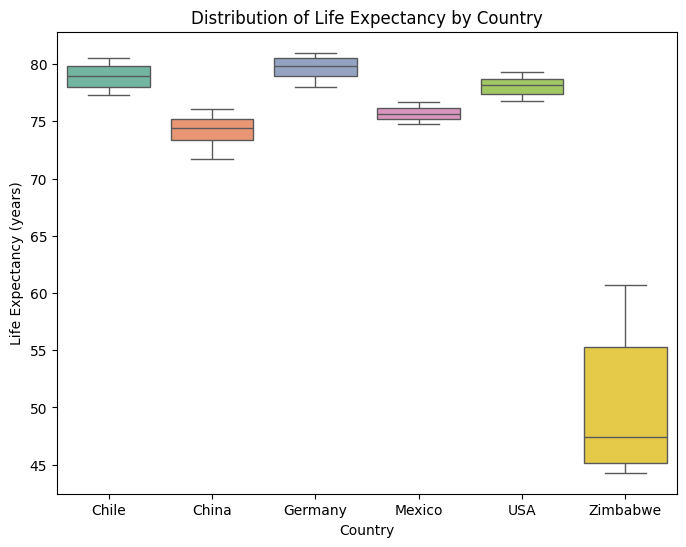

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
plt.title('Distribution of Life Expectancy by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy (years)')
plt.show()